In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

df = pd.read_csv("../dataset/processed/cleaned_data.csv")

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

y = df['Sentiment']

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test) 

In [6]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.76      0.66      0.71      1149
     neutral       0.65      0.70      0.67      1648
    positive       0.75      0.76      0.75      1708

    accuracy                           0.71      4505
   macro avg       0.72      0.71      0.71      4505
weighted avg       0.71      0.71      0.71      4505



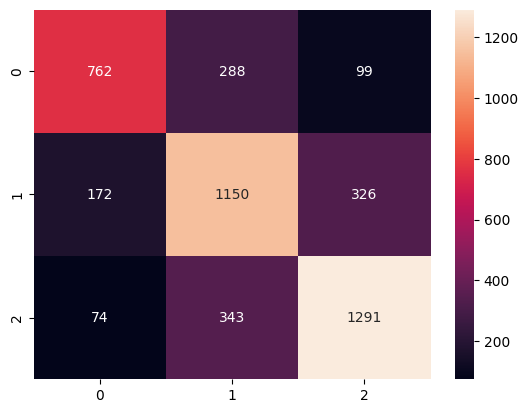

In [10]:
from sklearn.metrics import confusion_matrix 
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.show()

In [11]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

In [12]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

    negative       0.73      0.69      0.71      1149
     neutral       0.65      0.66      0.65      1648
    positive       0.74      0.76      0.75      1708

    accuracy                           0.70      4505
   macro avg       0.71      0.70      0.70      4505
weighted avg       0.70      0.70      0.70      4505



In [13]:
import joblib

joblib.dump(model, "../models/logistic_model.pkl")

joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']